<a href="https://colab.research.google.com/github/NextPlayAnalytics/volleyball-analytics-capstone/blob/main/notebooks/Volleyball_Stats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# Import Libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

In [2]:
# ============================================
# Load Dataset
# ============================================

df = pd.read_csv("/content/ncaa_volleyball_playermatchstats_2021.csv")


In [3]:
# ============================================
# Inspect Dataset
# ============================================

df.head()

df.info()

df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158755 entries, 0 to 158754
Data columns (total 26 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   date           158755 non-null  object 
 1   team           158755 non-null  object 
 2   player         158755 non-null  object 
 3   jersey         158755 non-null  int64  
 4   position       158642 non-null  object 
 5   opponent       158755 non-null  object 
 6   home_away      158755 non-null  object 
 7   result         158452 non-null  object 
 8   visitor_score  158480 non-null  float64
 9   home_score     158480 non-null  float64
 10  s              110205 non-null  float64
 11  ms             3750 non-null    float64
 12  kills          110205 non-null  float64
 13  errors         110205 non-null  float64
 14  total_attacks  110205 non-null  float64
 15  hit_pct        67715 non-null   float64
 16  assists        43577 non-null   float64
 17  aces           32272 non-null

Index(['date', 'team', 'player', 'jersey', 'position', 'opponent', 'home_away',
       'result', 'visitor_score', 'home_score', 's', 'ms', 'kills', 'errors',
       'total_attacks', 'hit_pct', 'assists', 'aces', 's_err', 'digs', 'r_err',
       'block_solos', 'block_assists', 'b_err', 'pts', 'bhe'],
      dtype='object')

In [4]:
# ============================================
# Position Distribution
# ============================================

df["position"].value_counts()


,count
position,
OH,50534
MB,34535
S,25179
L/DS,15238
DS,12106
RS,6852
L,6679
OPP,3884
MH,3635


In [5]:
# ============================================
# Hitting Percentage Summary Statistics
# ============================================

df["hit_pct"].describe()


,hit_pct
count,67715.000000
mean,0.214567
std,0.338989
min,-1.000000
25%,0.103000
50%,0.235000
75%,0.375000
max,1.000000


In [6]:
# ============================================
# Average Hitting Percentage by Position
# ============================================

df.groupby("position")["hit_pct"].mean().sort_values(ascending=False)



,hit_pct
position,
S,0.287047
MB,0.269105
MH,0.238984
L,0.230608
OPP,0.217661
RS,0.180479
DS,0.170942
OH,0.161650
L/DS,0.137022


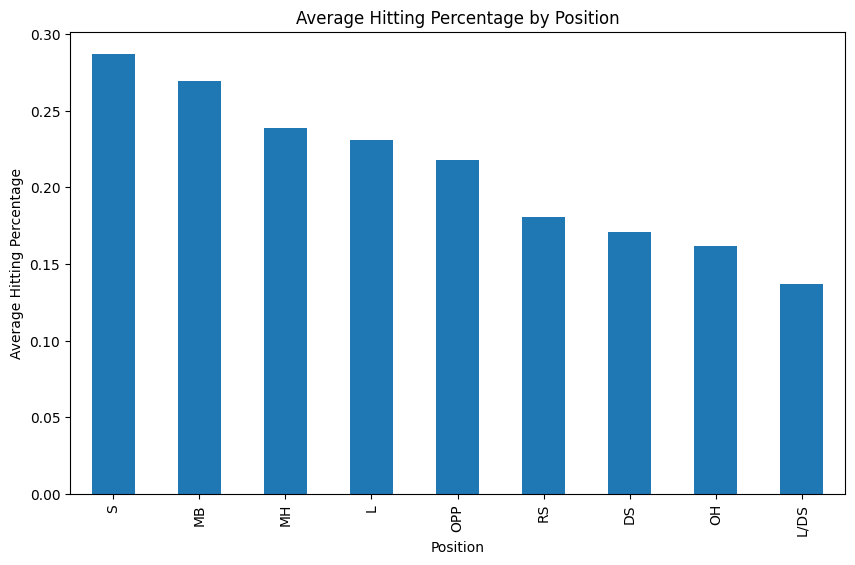

In [7]:
# ============================================
# Visualization:
# Average Hitting Percentage by Position
# ============================================

position_hitpct = (
    df.groupby("position")["hit_pct"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

position_hitpct.plot(kind="bar")

plt.title("Average Hitting Percentage by Position")
plt.xlabel("Position")
plt.ylabel("Average Hitting Percentage")

plt.savefig("avg_hit_pct_by_position.png", bbox_inches="tight")

plt.show()


In [8]:
# ============================================
# Download Visualization
# ============================================


files.download("avg_hit_pct_by_position.png")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
# ============================================
# Match Result Distribution
# ============================================

df["result"].value_counts()



,count
result,
Win,79353
Loss,79099


In [10]:
# ============================================
# Average Hitting Percentage by Match Result
# ============================================

df.groupby("result")["hit_pct"].mean()


,hit_pct
result,
Loss,0.146993
Win,0.281301


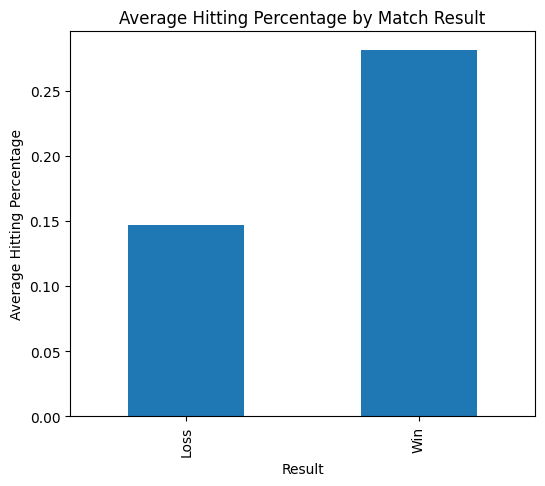

In [11]:
# ============================================
# Visualization:
# Average Hitting Percentage by Match Result
# ============================================

result_hitpct = df.groupby("result")["hit_pct"].mean()

plt.figure(figsize=(6,5))

result_hitpct.plot(kind="bar")

plt.title("Average Hitting Percentage by Match Result")
plt.xlabel("Result")
plt.ylabel("Average Hitting Percentage")

plt.show()


In [12]:
# ============================================
# Compare Metrics Between Wins and Losses
# ============================================

df.groupby("result")[[
    "kills",
    "errors",
    "hit_pct",
    "assists",
    "aces",
    "digs",
    "block_solos",
    "block_assists",
    "pts"
]].mean()


,kills,errors,hit_pct,assists,aces,digs,block_solos,block_assists,pts
result,,,,,,,,,
Loss,3.631300,1.894291,0.146993,8.819354,1.453110,6.025296,1.233856,2.195125,6.213763
Win,4.608375,1.583210,0.281301,10.198190,1.682554,6.631605,1.306190,2.538342,7.521481


In [13]:
# ============================================
# Correlation Analysis Dataset
# ============================================

correlation_data = df[[
    "kills",
    "errors",
    "total_attacks",
    "hit_pct",
    "assists",
    "aces",
    "digs",
    "block_solos",
    "block_assists",
    "pts"
]]


In [14]:
# ============================================
# Correlation Matrix
# ============================================

correlation_data.corr()



,kills,errors,total_attacks,hit_pct,assists,aces,digs,block_solos,block_assists,pts
kills,1.000000,0.696659,0.922106,0.249843,-0.196360,0.076834,-0.060070,0.049459,0.077072,0.972585
errors,0.696659,1.000000,0.824112,-0.290754,-0.220855,0.053965,-0.055373,-0.013529,-0.034390,0.609178
total_attacks,0.922106,0.824112,1.000000,0.017827,-0.196357,0.067301,-0.022744,0.013450,0.012162,0.874355
hit_pct,0.249843,-0.290754,0.017827,1.000000,0.084934,0.030380,-0.010624,0.060333,0.103663,0.137615
assists,-0.196360,-0.220855,-0.196357,0.084934,1.000000,0.015610,0.013874,-0.135229,-0.087074,-0.274075
aces,0.076834,0.053965,0.067301,0.030380,0.015610,1.000000,0.047411,0.008698,-0.006749,0.218573
digs,-0.060070,-0.055373,-0.022744,-0.010624,0.013874,0.047411,1.000000,-0.083574,-0.152824,-0.028327
block_solos,0.049459,-0.013529,0.013450,0.060333,-0.135229,0.008698,-0.083574,1.000000,0.069840,0.174675
block_assists,0.077072,-0.034390,0.012162,0.103663,-0.087074,-0.006749,-0.152824,0.069840,1.000000,0.228860
pts,0.972585,0.609178,0.874355,0.137615,-0.274075,0.218573,-0.028327,0.174675,0.228860,1.000000


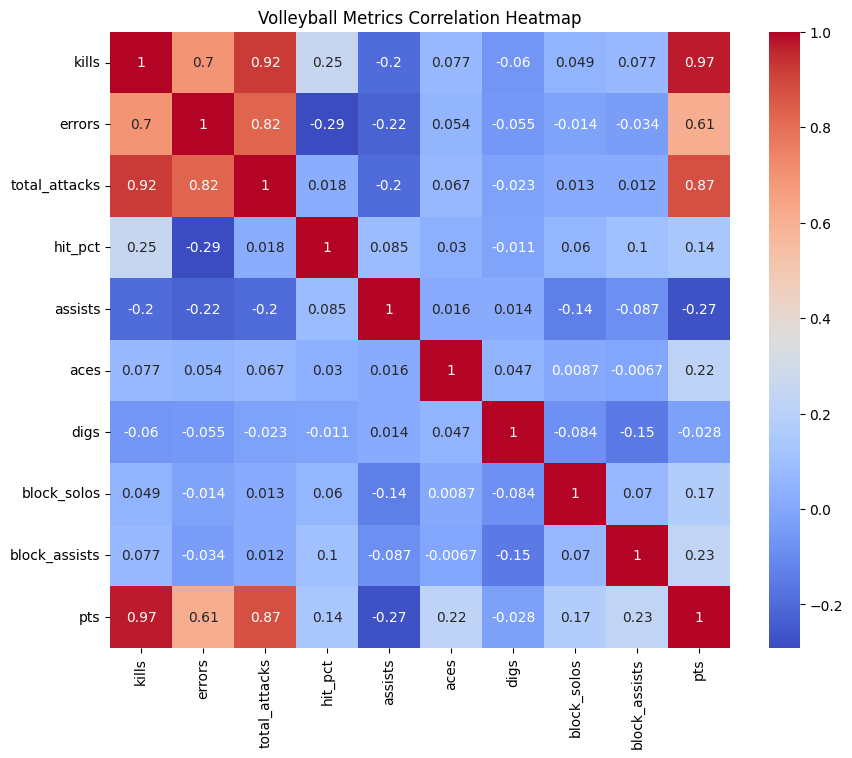

In [15]:
# ============================================
# Correlation Heatmap
# ============================================

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_data.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Volleyball Metrics Correlation Heatmap")

plt.savefig("volleyball_correlation_heatmap.png", bbox_inches="tight")

plt.show()


In [16]:
# ============================================
# Download Heatmap
# ============================================

files.download("volleyball_correlation_heatmap.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>